# Projet 9 — Analyse du catalogue musical MeloWave

## Mission 1 — Analyse exploratoire et tests statistiques

### Contexte

MeloWave est un distributeur musical indépendant qui accompagne des labels et des artistes sur les plateformes de streaming.

Dans le cadre de la préparation du comité éditorial, cette analyse vise à dresser un état des lieux chiffré du catalogue musical afin d'appuyer les recommandations faites aux labels sur des analyses de données.

La mission comprend trois étapes :

1. audit et nettoyage des données ;
2. analyse exploratoire du catalogue ;
3. tests statistiques permettant de répondre aux questions du comité.

In [557]:
# Path permet de gérer proprement les chemins vers les fichiers.
from pathlib import Path

# NumPy est utilisé pour les calculs numériques.
import numpy as np

# Pandas permet de charger, nettoyer et analyser les données.
import pandas as pd

# Matplotlib permet de créer les visualisations.
import matplotlib.pyplot as plt

# Afficher toutes les colonnes des DataFrames.
pd.set_option("display.max_columns", None)

# Limiter l'affichage des nombres décimaux à 3 chiffres après la virgule.
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [558]:
# Le notebook se trouve dans un dossier notebooks/
# On remonte donc d'un niveau avec "..", puis on entre dans P9/.
DATA_DIR = Path("../P9")

file_path = DATA_DIR / "spotify-tracks-dataset-detailed.csv"

df_raw = pd.read_csv(file_path)
df = df_raw.copy()

In [559]:
# Afficher les 5 premières observations afin de comprendre la structure des données.
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.032,0.000,0.358,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.076,0.924,0.000,0.101,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.056,0.210,0.000,0.117,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.060,0,-18.515,1,0.036,0.905,0.000,0.132,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.443,2,-9.681,1,0.053,0.469,0.000,0.083,0.167,119.949,4,acoustic


In [560]:
# Dimensions du jeu de données : nombre de lignes et nombre de colonnes.
df.shape

(114000, 20)

In [561]:
# Informations générales :
# - nom des colonnes
# - nombre de valeurs non nulles
# - type Python de chaque colonne
# - mémoire utilisée
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [562]:
# Liste complète des colonnes.
df.columns.tolist()

['track_id',
 'artists',
 'album_name',
 'track_name',
 'popularity',
 'duration_ms',
 'explicit',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature',
 'track_genre']

### Dimensions et structure


Le jeu de données contient initialement **114 000 observations et 20 variables**.

Il comprend des informations d'identification sur les morceaux, les artistes et les albums, ainsi que plusieurs caractéristiques audio, un score de popularité, une information sur le caractère explicite et un genre musical.

Un même morceau peut apparaître plusieurs fois lorsqu'il est associé à plusieurs genres. Une occurrence multiple d'un `track_id` ne constitue donc pas nécessairement une erreur.

In [563]:
# Construction d'un tableau résumant :
# - le type Python
# - le nombre de valeurs non nulles
# - le nombre de valeurs différentes pour chaque variable
variables_info = pd.DataFrame({
    "type_python": df.dtypes,
    "nombre_non_nulles": df.notna().sum(),
    "nombre_uniques": df.nunique(dropna=False)
})

variables_info

,type_python,nombre_non_nulles,nombre_uniques
track_id,object,114000,89741
artists,object,113999,31438
album_name,object,113999,46590
track_name,object,113999,73609
popularity,int64,114000,101
duration_ms,int64,114000,50697
explicit,bool,114000,2
danceability,float64,114000,1174
energy,float64,114000,2083
key,int64,114000,12


In [564]:
# Nombre et pourcentage de valeurs manquantes pour chaque colonne.
missing_values = pd.DataFrame({
    "nombre_manquant": df.isna().sum(),
    "pourcentage": df.isna().mean() * 100
})

# On trie les variables les plus concernées en premier.
missing_values.sort_values(
    "nombre_manquant",
    ascending=False
)

,nombre_manquant,pourcentage
album_name,1,0.001
track_name,1,0.001
artists,1,0.001
track_id,0,0.000
speechiness,0,0.000
time_signature,0,0.000
tempo,0,0.000
valence,0,0.000
liveness,0,0.000
instrumentalness,0,0.000


In [565]:
# Afficher seulement les variables contenant au moins une valeur manquante.
missing_values[
    missing_values["nombre_manquant"] > 0
]

,nombre_manquant,pourcentage
artists,1,0.001
album_name,1,0.001
track_name,1,0.001


In [566]:
# Afficher les observations contenant au moins une valeur manquante.
df[df.isna().any(axis=1)]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.460,0,0.060,0.690,0.004,0.075,0.734,138.391,4,k-pop


In [567]:
# On garde le nombre de lignes avant suppression afin de documenter le nettoyage.
n_before_missing = len(df)

# Suppression des observations pour lesquelles les informations
# d'identification du morceau ou de l'artiste sont absentes.
df = df.dropna(
    subset=["artists", "album_name", "track_name"]
).copy()

# Nombre de lignes après suppression.
n_after_missing = len(df)

print(f"Lignes avant : {n_before_missing:,}")
print(f"Lignes après : {n_after_missing:,}")
print(
    f"Lignes supprimées : "
    f"{n_before_missing - n_after_missing:,}"
)

Lignes avant : 114,000
Lignes après : 113,999
Lignes supprimées : 1


### Traitement des valeurs manquantes

Une seule observation contient des valeurs manquantes simultanément pour `artists`, `album_name` et `track_name`.

Ces informations étant nécessaires aux analyses portant sur les artistes et les morceaux, cette observation a été supprimée.

La suppression porte sur une seule ligne parmi 114 000 observations et son impact sur les résultats est donc négligeable.

In [568]:
# Un doublon strict correspond à une ligne identique
# sur l'ensemble des colonnes.
n_strict_duplicates = df.duplicated().sum()

print(
    f"Nombre de doublons stricts : "
    f"{n_strict_duplicates:,}"
)

Nombre de doublons stricts : 450


In [569]:
# Afficher quelques doublons stricts afin de vérifier leur nature.
df[
    df.duplicated(keep=False)
].sort_values(
    ["track_id", "track_genre"]
).head(20)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
52714,00JZ83w0Qm09f4PwWj06sM,George Jones,With Love,A Good Year For The Roses,12,190546,False,0.491,0.334,11,-9.684,1,0.029,0.659,0.000,0.116,0.249,91.674,4,honky-tonk
52766,00JZ83w0Qm09f4PwWj06sM,George Jones,With Love,A Good Year For The Roses,12,190546,False,0.491,0.334,11,-9.684,1,0.029,0.659,0.000,0.116,0.249,91.674,4,honky-tonk
39275,02KmEChUwcjxG3G29kbLFT,Hans Zimmer;Henning Lohner;Martin Tillman;Fiac...,Hans Zimmer: Epic Scores,Shelter Mountain,16,250520,False,0.144,0.262,9,-21.228,1,0.064,0.876,0.755,0.144,0.035,94.430,4,german
39307,02KmEChUwcjxG3G29kbLFT,Hans Zimmer;Henning Lohner;Martin Tillman;Fiac...,Hans Zimmer: Epic Scores,Shelter Mountain,16,250520,False,0.144,0.262,9,-21.228,1,0.064,0.876,0.755,0.144,0.035,94.430,4,german
93331,02MRylJ1WAgxzdqfNfdIsR,Oleg Pogudin,Любовь и разлука. Песни Исаака Шварца,"Город пышный, город бедный",0,114600,False,0.446,0.121,4,-12.737,0,0.041,0.937,0.000,0.125,0.180,107.573,3,romance
93376,02MRylJ1WAgxzdqfNfdIsR,Oleg Pogudin,Любовь и разлука. Песни Исаака Шварца,"Город пышный, город бедный",0,114600,False,0.446,0.121,4,-12.737,0,0.041,0.937,0.000,0.125,0.180,107.573,3,romance
16747,03B8ZXUmuDpf59j5PIMFHq,Wolfgang Amadeus Mozart;Heinz Holliger;Academy...,Mozart - All Day Classics,"Ma che vi fece... Sperai vicino, K.368: 1. And...",7,86160,False,0.290,0.049,5,-24.072,1,0.056,0.980,0.753,0.108,0.114,76.473,4,classical
16947,03B8ZXUmuDpf59j5PIMFHq,Wolfgang Amadeus Mozart;Heinz Holliger;Academy...,Mozart - All Day Classics,"Ma che vi fece... Sperai vicino, K.368: 1. And...",7,86160,False,0.290,0.049,5,-24.072,1,0.056,0.980,0.753,0.108,0.114,76.473,4,classical
16723,040CvqW0wo3b77EBRfgC14,Wolfgang Amadeus Mozart;Isabelle van Keulen;Ro...,Mozart - A Classical Dawn,Andante and allegretto for Piano and Violin in...,6,84653,False,0.446,0.106,7,-21.427,1,0.046,0.987,0.696,0.101,0.844,157.273,4,classical
16923,040CvqW0wo3b77EBRfgC14,Wolfgang Amadeus Mozart;Isabelle van Keulen;Ro...,Mozart - A Classical Dawn,Andante and allegretto for Piano and Violin in...,6,84653,False,0.446,0.106,7,-21.427,1,0.046,0.987,0.696,0.101,0.844,157.273,4,classical


In [570]:
# Nombre de lignes avant suppression des doublons stricts.
n_before_duplicates = len(df)

# Suppression des lignes parfaitement identiques.
df = df.drop_duplicates().copy()

# Nombre de lignes après suppression.
n_after_duplicates = len(df)

print(f"Lignes avant : {n_before_duplicates:,}")
print(f"Lignes après : {n_after_duplicates:,}")
print(
    f"Doublons supprimés : "
    f"{n_before_duplicates - n_after_duplicates:,}"
)

Lignes avant : 113,999
Lignes après : 113,549
Doublons supprimés : 450


### Traitement des doublons stricts

L'audit a identifié **450 doublons stricts**.

Ces observations étant identiques sur toutes les variables, elles n'apportent aucune information supplémentaire.

Elles ont donc été supprimées.

In [571]:
# Nombre total d'observations après nettoyage.
print(f"Nombre de lignes : {len(df):,}")

# Nombre réel de morceaux différents.
print(
    f"Nombre de track_id uniques : "
    f"{df['track_id'].nunique():,}"
)

# Différence entre le nombre de lignes et le nombre de morceaux.
print(
    f"Occurrences supplémentaires : "
    f"{len(df) - df['track_id'].nunique():,}"
)

Nombre de lignes : 113,549
Nombre de track_id uniques : 89,740
Occurrences supplémentaires : 23,809


In [572]:
# Sélectionner uniquement les morceaux apparaissant plusieurs fois.
duplicated_track_ids = df[
    df["track_id"].duplicated(keep=False)
]

# Vérifier si les répétitions correspondent à différents genres.
duplicated_track_ids[
    [
        "track_id",
        "track_name",
        "artists",
        "track_genre"
    ]
].sort_values("track_id").head(30)

,track_id,track_name,artists,track_genre
15028,001APMDOl3qtx1526T11n1,Better,Pink Sweat$;Kirby,chill
103211,001APMDOl3qtx1526T11n1,Better,Pink Sweat$;Kirby,soul
85578,001YQlnDSduXd5LgBd66gT,El Tiempo Es Dinero - Remasterizado 2007,Soda Stereo,punk-rock
100420,001YQlnDSduXd5LgBd66gT,El Tiempo Es Dinero - Remasterizado 2007,Soda Stereo,ska
2106,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,alt-rock
91801,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,rock
3257,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,alternative
33178,004h8smbIoAkUNDJvVKwkG,Lovemark,Ouse;Powfu,emo
94239,004h8smbIoAkUNDJvVKwkG,Lovemark,Ouse;Powfu,sad
97533,006rHBBNLJMpQs8fRC2GDe,Agora Estou Sofrendo - Ao Vivo,Calcinha Preta;Gusttavo Lima,sertanejo


In [573]:
# Pour chaque morceau, compter le nombre de genres différents associés.
genres_per_track = (
    df.groupby("track_id")["track_genre"]
      .nunique()
)

# Distribution du nombre de genres par morceau.
genres_per_track.value_counts().sort_index()

track_genre
1    73441
2    11424
3     2955
4     1361
5      431
6      104
7       21
8        2
9        1
Name: count, dtype: int64

In [574]:
# Nombre de morceaux apparaissant dans au moins deux genres différents.
n_multigenre = (
    genres_per_track > 1
).sum()

print(
    f"Morceaux associés à plusieurs genres : "
    f"{n_multigenre:,}"
)

Morceaux associés à plusieurs genres : 16,299


### Gestion des morceaux associés à plusieurs genres

Les occurrences multiples d'un même `track_id` ne sont pas considérées comme des erreurs lorsqu'elles correspondent à différents genres musicaux.

Au total, 16 299 de morceaux sont associés à plusieurs genres, ce qui montre qu'il s'agit d'une caractéristique structurelle du jeu de données.

Ces observations seront donc conservées pour les analyses par genre.

En revanche, une table comportant une seule observation par morceau sera également créée pour les analyses globales afin d'éviter de compter plusieurs fois le même titre.

In [575]:
# Caractéristiques qui devraient rester identiques
# pour un même morceau quel que soit son genre.
audio_columns = [
    "duration_ms",
    "explicit",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature"
]

# Pour chaque track_id :
# si une caractéristique possède plusieurs valeurs,
# cela indique une incohérence potentielle.
audio_inconsistencies = (
    df.groupby("track_id")[audio_columns]
      .nunique(dropna=False)
      .gt(1)
      .sum()
)

audio_inconsistencies

duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
dtype: int64

In [576]:
# La popularité est vérifiée séparément car elle peut varier
# entre plusieurs occurrences d'un même track_id.
popularity_variations = (
    df.groupby("track_id")["popularity"]
      .nunique()
)

print(
    "Nombre de morceaux ayant plusieurs scores de popularité :",
    (popularity_variations > 1).sum()
)

Nombre de morceaux ayant plusieurs scores de popularité : 720


In [577]:
# Trier d'abord les observations par popularité décroissante.
# Ainsi, lorsqu'un track_id apparaît plusieurs fois,
# sa valeur de popularité maximale sera placée en premier.
df_tracks = (
    df.sort_values(
        "popularity",
        ascending=False
    )
    .drop_duplicates(
        subset="track_id",
        keep="first"
    )
    .copy()
)

print(
    f"Table morceau-genre : {len(df):,} lignes"
)

print(
    f"Table morceaux uniques : {len(df_tracks):,} lignes"
)

Table morceau-genre : 113,549 lignes
Table morceaux uniques : 89,740 lignes


Pour les analyses globales du catalogue, une seconde table contenant une seule observation par `track_id` a été créée.

Lorsque plusieurs scores de popularité existent pour le même morceau, la valeur maximale observée est conservée pour les classements globaux.

La table complète reste néanmoins utilisée pour les analyses portant spécifiquement sur les genres.

In [578]:
# Spotify fournit la durée en millisecondes.
# La conversion en secondes facilite l'interprétation métier.
df["duration_seconds"] = (
    df["duration_ms"] / 1000
)

df_tracks["duration_seconds"] = (
    df_tracks["duration_ms"] / 1000
)

In [579]:
# Vérification de la conversion.
df[
    [
        "track_name",
        "duration_ms",
        "duration_seconds"
    ]
].head()

,track_name,duration_ms,duration_seconds
0,Comedy,230666,230.666
1,Ghost - Acoustic,149610,149.610
2,To Begin Again,210826,210.826
3,Can't Help Falling In Love,201933,201.933
4,Hold On,198853,198.853


In [580]:
# Tableau synthétique permettant de documenter
# le nombre de lignes avant et après chaque opération.
cleaning_report = pd.DataFrame({
    "operation": [
        "Données initiales",
        "Suppression des valeurs manquantes",
        "Suppression des doublons stricts"
    ],
    "nombre_de_lignes": [
        len(df_raw),
        n_after_missing,
        len(df)
    ]
})

cleaning_report

,operation,nombre_de_lignes
0,Données initiales,114000
1,Suppression des valeurs manquantes,113999
2,Suppression des doublons stricts,113549


In [581]:
# Vérifications finales avant de commencer l'analyse exploratoire.

print(
    f"Valeurs manquantes restantes : "
    f"{df.isna().sum().sum()}"
)

print(
    f"Doublons stricts restants : "
    f"{df.duplicated().sum()}"
)

print(
    f"Nombre de lignes finales : "
    f"{len(df):,}"
)

print(
    f"Nombre de morceaux uniques : "
    f"{df['track_id'].nunique():,}"
)

Valeurs manquantes restantes : 0
Doublons stricts restants : 0
Nombre de lignes finales : 113,549
Nombre de morceaux uniques : 89,740


In [582]:
# Variables quantitatives étudiées dans l'analyse exploratoire.
numeric_vars = [
    "popularity",
    "duration_seconds",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

In [583]:
# describe() permet d'obtenir :
# moyenne, écart-type, minimum, quartiles et maximum.
# On utilise df_tracks afin qu'un même morceau ne soit compté qu'une fois.
numeric_description = (
    df_tracks[numeric_vars]
    .describe()
    .T
)

numeric_description

,count,mean,std,min,25%,50%,75%,max
popularity,89740.000,33.208,20.574,0.000,19.000,33.000,49.000,100.000
duration_seconds,89740.000,229.144,112.946,8.586,173.040,213.296,264.293,5237.295
danceability,89740.000,0.562,0.177,0.000,0.450,0.576,0.692,0.985
energy,89740.000,0.634,0.257,0.000,0.457,0.676,0.853,1.000
loudness,89740.000,-8.499,5.222,-49.531,-10.322,-7.185,-5.108,4.532
speechiness,89740.000,0.087,0.113,0.000,0.036,0.049,0.086,0.965
acousticness,89740.000,0.328,0.338,0.000,0.017,0.188,0.625,0.996
instrumentalness,89740.000,0.173,0.324,0.000,0.000,0.000,0.098,1.000
liveness,89740.000,0.217,0.195,0.000,0.098,0.132,0.279,1.000
valence,89740.000,0.469,0.263,0.000,0.249,0.457,0.682,0.995


### Statistiques descriptives

Les statistiques descriptives permettent d'évaluer le niveau moyen, la dispersion et l'étendue des différentes caractéristiques audio.

Les moyennes ne doivent cependant pas être interprétées seules car plusieurs distributions sont susceptibles d'être fortement asymétriques.

In [584]:
# Résumé des variables catégorielles principales.
df[
    [
        "artists",
        "explicit",
        "track_genre"
    ]
].describe(include="all")

,artists,explicit,track_genre
count,113549,113549,113549
unique,31437,2,114
top,The Beatles,False,acoustic
freq,279,103831,1000


In [585]:
# Nombre total de genres disponibles dans le catalogue.
df["track_genre"].nunique()

114

In [586]:
# Calcul de la proportion de morceaux avec un score de popularité nul.
zero_popularity_rate = (
    (df_tracks["popularity"] == 0).mean() * 100
)

print(
    f"Proportion de morceaux avec popularité = 0 : "
    f"{zero_popularity_rate:.2f}%"
)

Proportion de morceaux avec popularité = 0 : 10.42%


### Popularité nulle

Une part non négligeable du catalogue présente un score de popularité égal à 0.

Cette concentration sur la valeur minimale influence la forme de la distribution et devra être prise en compte lors de l'analyse de normalité et du choix des tests statistiques.

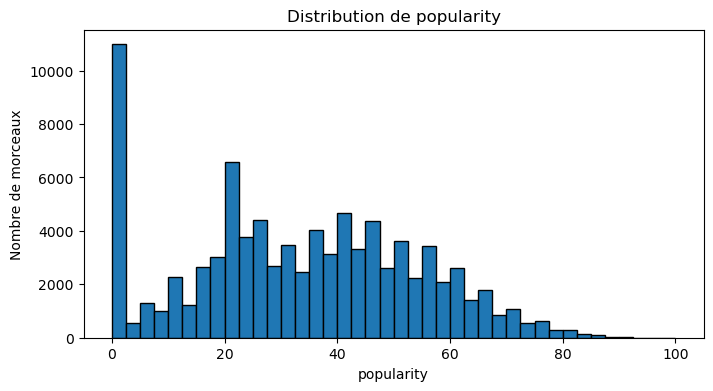

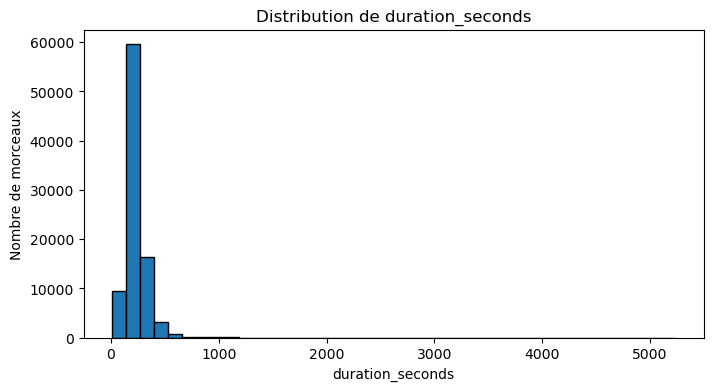

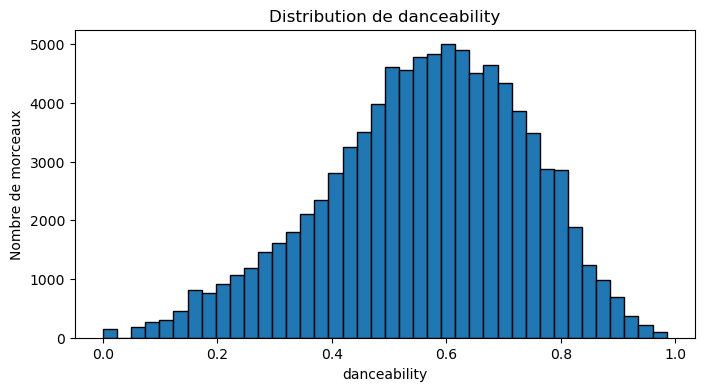

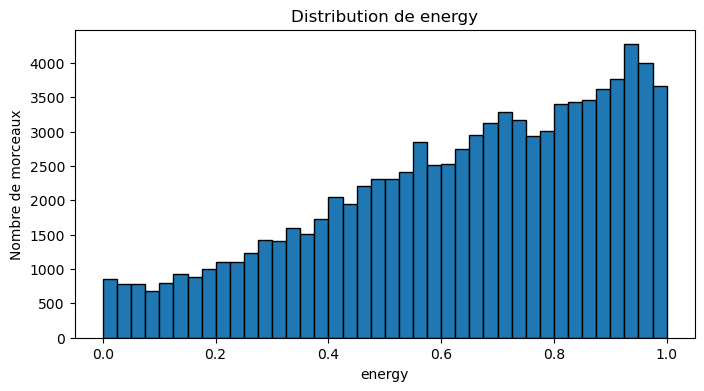

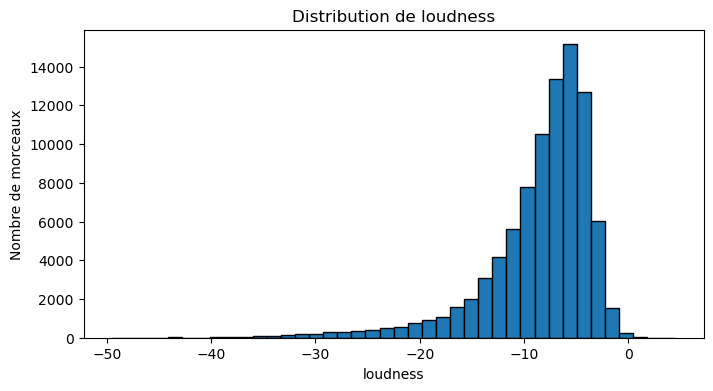

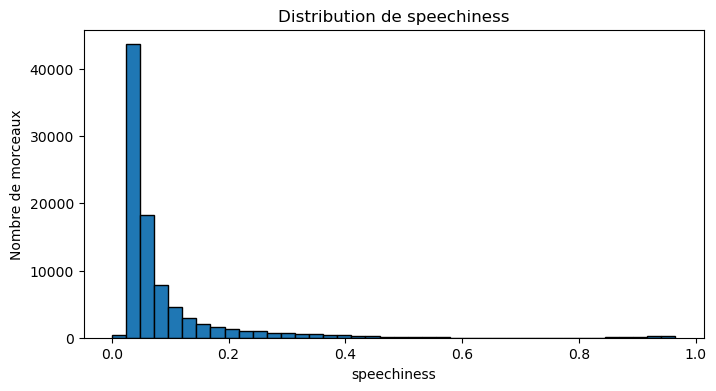

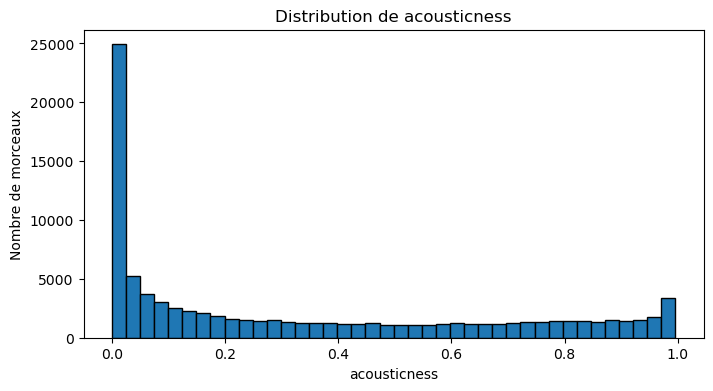

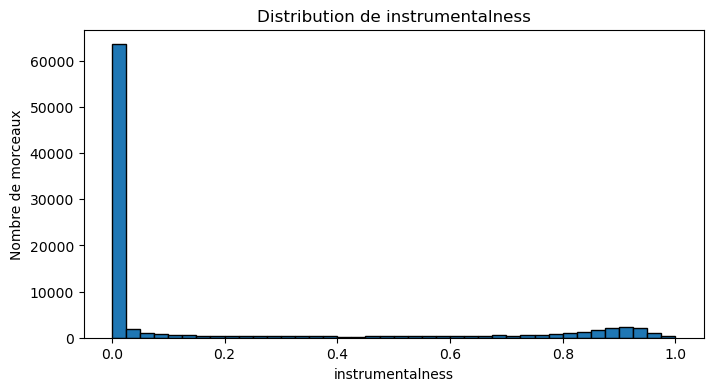

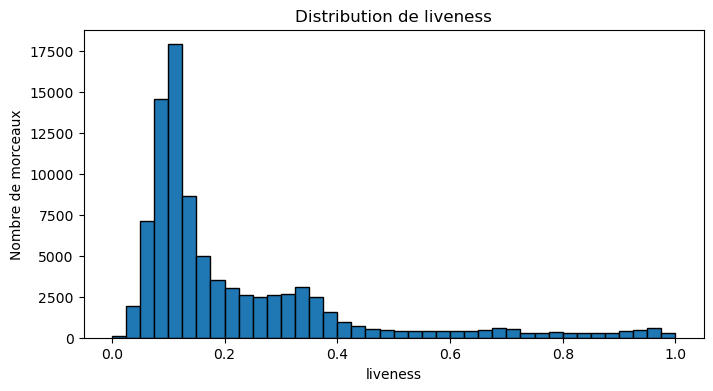

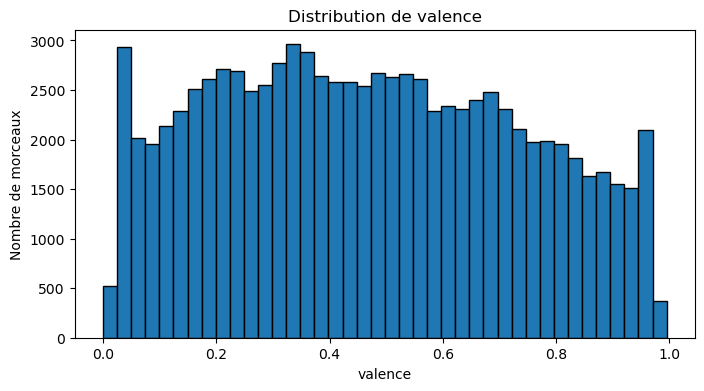

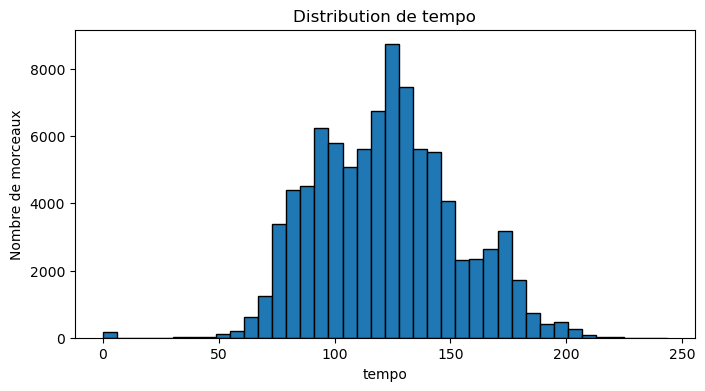

In [587]:
# Création d'un histogramme pour chaque variable numérique.
# Les histogrammes permettent d'observer la forme générale
# des distributions et leur éventuelle asymétrie.

for variable in numeric_vars:
    
    plt.figure(figsize=(8, 4))
    
    plt.hist(
        df_tracks[variable].dropna(),
        bins=40,
        edgecolor="black"
    )
    
    plt.title(
        f"Distribution de {variable}"
    )
    
    plt.xlabel(variable)
    plt.ylabel("Nombre de morceaux")
    
    plt.show()

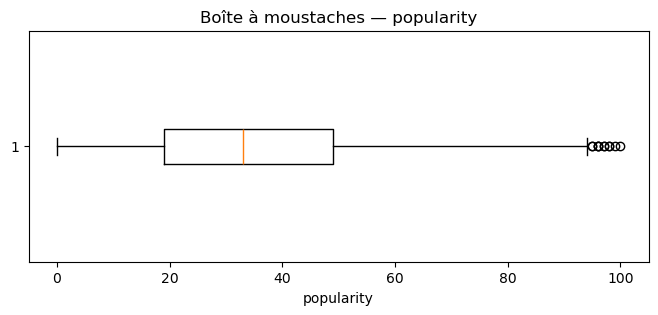

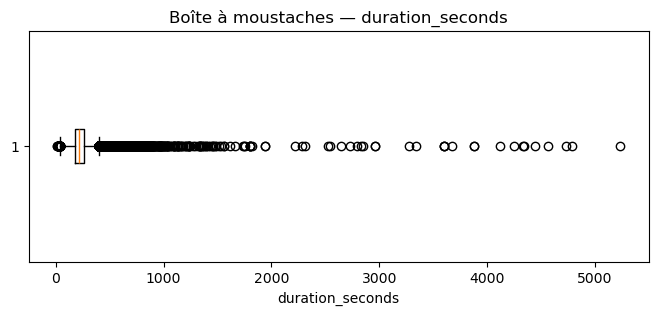

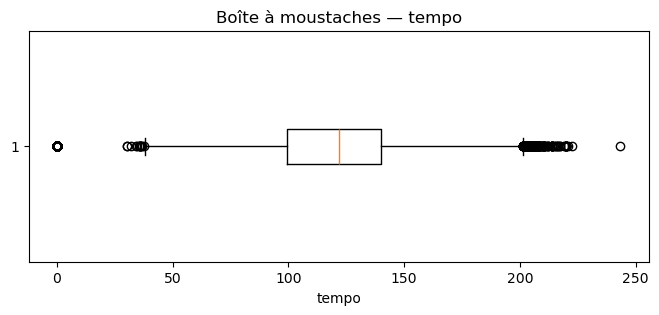

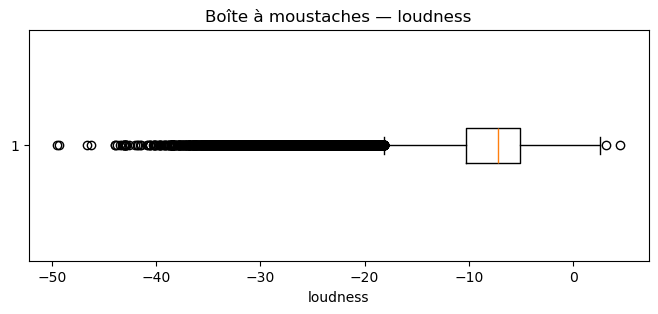

In [588]:
# Les boîtes à moustaches permettent d'identifier rapidement
# la médiane, la dispersion et les valeurs statistiquement atypiques.

boxplot_vars = [
    "popularity",
    "duration_seconds",
    "tempo",
    "loudness"
]

for variable in boxplot_vars:
    
    plt.figure(figsize=(8, 3))
    
    plt.boxplot(
        df_tracks[variable].dropna(),
        vert=False
    )
    
    plt.title(
        f"Boîte à moustaches — {variable}"
    )
    
    plt.xlabel(variable)
    
    plt.show()

In [589]:
# Skewness = asymétrie de la distribution.
# Kurtosis = importance des queues / valeurs extrêmes.
shape_analysis = pd.DataFrame({
    "skewness": df_tracks[numeric_vars].skew(),
    "kurtosis": df_tracks[numeric_vars].kurt()
})

shape_analysis

,skewness,kurtosis
popularity,0.071,-0.770
duration_seconds,11.073,331.980
danceability,-0.398,-0.194
energy,-0.560,-0.608
loudness,-1.960,5.470
speechiness,4.546,26.567
acousticness,0.656,-1.066
instrumentalness,1.564,0.680
liveness,2.062,4.075
valence,0.128,-1.047


In [590]:
# Fonction permettant de calculer les bornes IQR.
# Une observation est considérée comme atypique si elle est
# inférieure à Q1 - 1.5*IQR ou supérieure à Q3 + 1.5*IQR.

def detect_iqr_outliers(series):
    
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]
    
    return lower_bound, upper_bound, outliers

In [591]:
# L'énoncé demande explicitement duration, tempo et loudness.
for variable in [
    "duration_seconds",
    "tempo",
    "loudness"
]:
    
    lower, upper, outliers = detect_iqr_outliers(
        df_tracks[variable]
    )
    
    print(f"\n--- {variable} ---")
    print(f"Borne basse : {lower:.2f}")
    print(f"Borne haute : {upper:.2f}")
    print(f"Nombre d'outliers : {len(outliers):,}")
    
    print(
        f"Pourcentage : "
        f"{len(outliers) / len(df_tracks) * 100:.2f}%"
    )


--- duration_seconds ---
Borne basse : 36.16
Borne haute : 401.17
Nombre d'outliers : 4,225
Pourcentage : 4.71%

--- tempo ---
Borne basse : 38.04
Borne haute : 201.30
Nombre d'outliers : 514
Pourcentage : 0.57%

--- loudness ---
Borne basse : -18.14
Borne haute : 2.71
Nombre d'outliers : 5,026
Pourcentage : 5.60%


### Traitement des valeurs aberrantes

La méthode IQR identifie plusieurs observations statistiquement atypiques concernant notamment la durée, le tempo et le niveau sonore.

Ces valeurs ne sont pas automatiquement supprimées. Une valeur statistiquement extrême peut correspondre à un morceau réel, par exemple une œuvre particulièrement longue ou un morceau possédant un tempo atypique.

En l'absence d'élément indiquant une erreur de mesure ou de collecte, ces observations sont donc conservées.

In [592]:
# Division des chaînes contenant plusieurs artistes.
# explode() transforme ensuite chaque artiste en une ligne séparée.
artists_exploded = (
    df_tracks["artists"]
    .str.split(";")
    .explode()
    .str.strip()
)

# Compter le nombre de morceaux associé à chaque artiste.
top_artists_presence = (
    artists_exploded
    .value_counts()
    .head(15)
)

top_artists_presence

artists
George Jones               332
Pritam                     323
Wolfgang Amadeus Mozart    305
Arijit Singh               259
Hank Williams              243
my little airport          171
Glee Cast                  170
Yuvan Shankar Raja         167
Hillsong Worship           167
BTS                        165
J Balvin                   156
Linkin Park                154
Hans Zimmer                153
The Beatles                150
Håkan Hellström            143
Name: count, dtype: int64

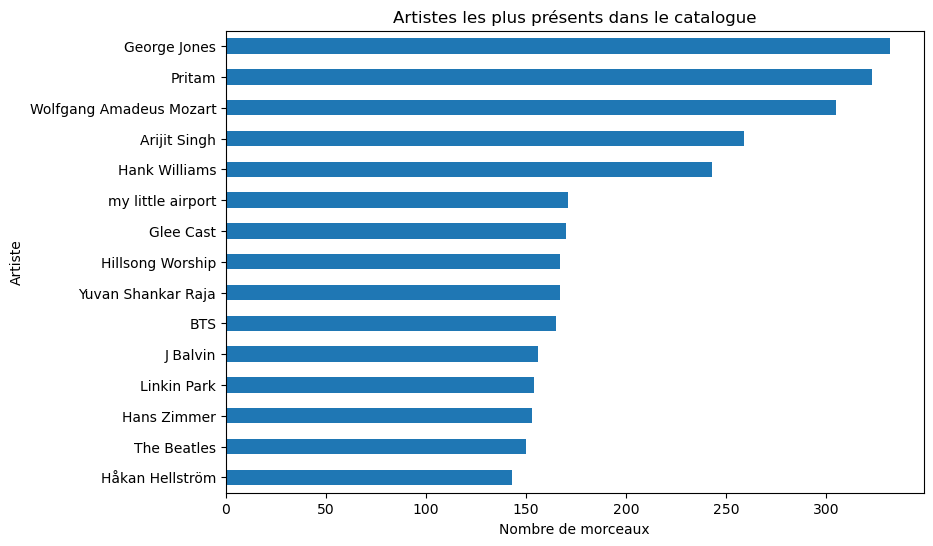

In [593]:
# Visualisation des artistes les plus présents dans le catalogue.
plt.figure(figsize=(9, 6))

top_artists_presence.sort_values().plot(
    kind="barh"
)

plt.xlabel("Nombre de morceaux")
plt.ylabel("Artiste")
plt.title(
    "Artistes les plus présents dans le catalogue"
)

plt.show()

In [594]:
# On conserve à la fois le track_id,
# la liste d'artistes et la popularité.
artists_popularity = (
    df_tracks[
        ["track_id", "artists", "popularity"]
    ]
    .copy()
)

# Séparation des collaborations / featurings.
artists_popularity["artists"] = (
    artists_popularity["artists"]
    .str.split(";")
)

# Une ligne par artiste.
artists_popularity = (
    artists_popularity
    .explode("artists")
)

# Nettoyage des espaces éventuels autour des noms.
artists_popularity["artists"] = (
    artists_popularity["artists"]
    .str.strip()
)

In [595]:
# Calcul du nombre de morceaux et de la popularité moyenne
# de chaque artiste.
artist_stats = (
    artists_popularity
    .groupby("artists")
    .agg(
        nb_morceaux=("track_id", "nunique"),
        popularite_moyenne=("popularity", "mean")
    )
)

In [596]:
# Seuls les artistes disposant d'au moins 5 morceaux
# sont inclus dans le classement de popularité moyenne.
# Cela évite qu'un artiste avec un seul titre très populaire
# domine artificiellement le classement.
MIN_TRACKS = 5

In [597]:
top_popular_artists = (
    artist_stats[
        artist_stats["nb_morceaux"] >= MIN_TRACKS
    ]
    .sort_values(
        "popularite_moyenne",
        ascending=False
    )
    .head(15)
)

top_popular_artists

,nb_morceaux,popularite_moyenne
artists,,
Olivia Rodrigo,5,87.400
One Direction,5,83.000
Lil Nas X,8,82.750
Måneskin,5,82.600
Mora,6,80.333
Mitski,6,78.333
Shubh,5,77.800
Frank Ocean,21,74.143
Limp Bizkit,6,73.833


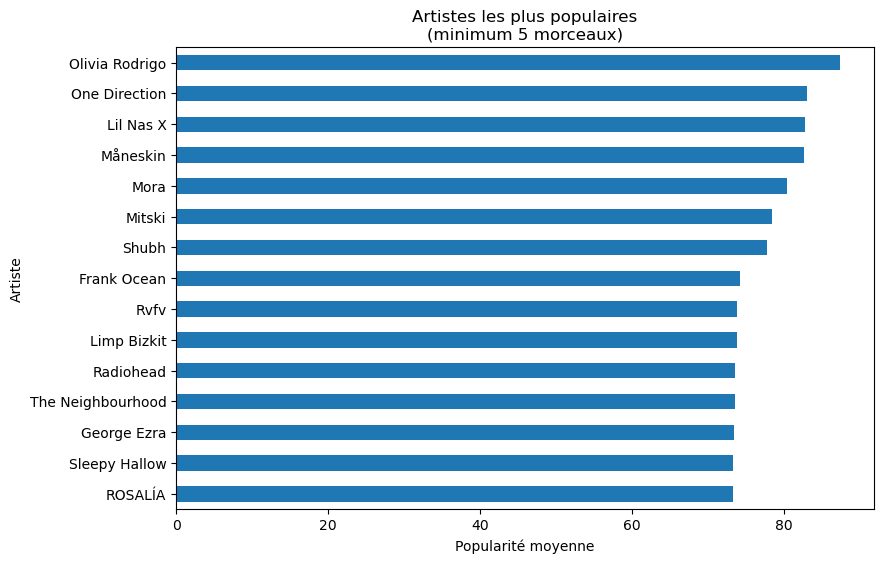

In [598]:
plt.figure(figsize=(9, 6))

top_popular_artists[
    "popularite_moyenne"
].sort_values().plot(
    kind="barh"
)

plt.xlabel("Popularité moyenne")
plt.ylabel("Artiste")
plt.title(
    "Artistes les plus populaires\n"
    f"(minimum {MIN_TRACKS} morceaux)"
)

plt.show()

In [599]:
# Classement des morceaux par popularité maximale observée.
top_tracks = (
    df_tracks[
        [
            "track_name",
            "artists",
            "popularity"
        ]
    ]
    .sort_values(
        "popularity",
        ascending=False
    )
    .head(15)
)

top_tracks

,track_name,artists,popularity
81051,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,99
68303,La Bachata,Manuel Turizo,98
81210,I'm Good (Blue),David Guetta;Bebe Rexha,98
88405,Me Porto Bonito,Bad Bunny;Chencho Corleone,97
88407,Tití Me Preguntó,Bad Bunny,97
79000,I Ain't Worried,OneRepublic,96
20000,Under The Influence,Chris Brown,96
67559,Efecto,Bad Bunny,96
81052,As It Was,Harry Styles,95


In [600]:
# Vérifier les noms exacts disponibles dans le dataset.
sorted(df["track_genre"].unique())

['acoustic',
 'afrobeat',
 'alt-rock',
 'alternative',
 'ambient',
 'anime',
 'black-metal',
 'bluegrass',
 'blues',
 'brazil',
 'breakbeat',
 'british',
 'cantopop',
 'chicago-house',
 'children',
 'chill',
 'classical',
 'club',
 'comedy',
 'country',
 'dance',
 'dancehall',
 'death-metal',
 'deep-house',
 'detroit-techno',
 'disco',
 'disney',
 'drum-and-bass',
 'dub',
 'dubstep',
 'edm',
 'electro',
 'electronic',
 'emo',
 'folk',
 'forro',
 'french',
 'funk',
 'garage',
 'german',
 'gospel',
 'goth',
 'grindcore',
 'groove',
 'grunge',
 'guitar',
 'happy',
 'hard-rock',
 'hardcore',
 'hardstyle',
 'heavy-metal',
 'hip-hop',
 'honky-tonk',
 'house',
 'idm',
 'indian',
 'indie',
 'indie-pop',
 'industrial',
 'iranian',
 'j-dance',
 'j-idol',
 'j-pop',
 'j-rock',
 'jazz',
 'k-pop',
 'kids',
 'latin',
 'latino',
 'malay',
 'mandopop',
 'metal',
 'metalcore',
 'minimal-techno',
 'mpb',
 'new-age',
 'opera',
 'pagode',
 'party',
 'piano',
 'pop',
 'pop-film',
 'power-pop',
 'progressive

In [601]:
# Genres volontairement contrastés.
selected_genres = [
    "classical",
    "metal",
    "dance",
    "acoustic"
]

In [602]:
# Variables compatibles avec une comparaison directe sur le radar.
radar_vars = [
    "danceability",
    "energy",
    "acousticness",
    "instrumentalness",
    "valence",
    "liveness"
]

In [603]:
# Profil moyen de chaque genre.
genre_profiles = (
    df[
        df["track_genre"].isin(
            selected_genres
        )
    ]
    .groupby("track_genre")[radar_vars]
    .mean()
)

genre_profiles

,danceability,energy,acousticness,instrumentalness,valence,liveness
track_genre,,,,,,
acoustic,0.550,0.435,0.567,0.038,0.424,0.153
classical,0.382,0.195,0.917,0.608,0.379,0.166
dance,0.688,0.710,0.131,0.009,0.552,0.168
metal,0.464,0.841,0.037,0.065,0.418,0.205


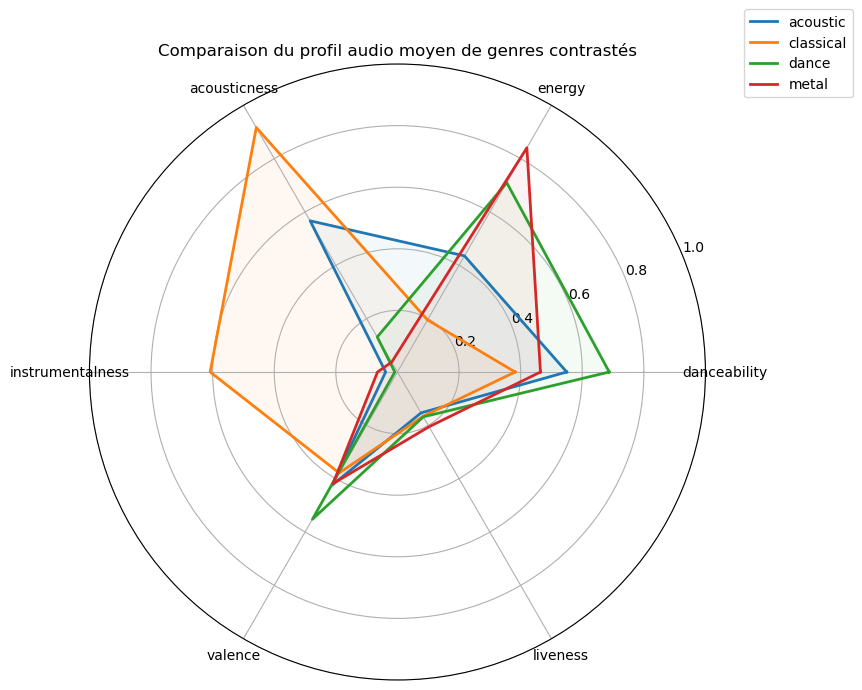

In [604]:
# Nombre de variables représentées sur le radar.
n_variables = len(radar_vars)

# Création des angles correspondant à chaque variable.
angles = np.linspace(
    0,
    2 * np.pi,
    n_variables,
    endpoint=False
).tolist()

# On répète le premier angle afin de fermer le radar.
angles += angles[:1]

# Création d'une figure polaire.
fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw={"polar": True}
)

# Une courbe par genre.
for genre, row in genre_profiles.iterrows():
    
    values = row.tolist()
    
    # Répéter la première valeur pour fermer la forme.
    values += values[:1]
    
    ax.plot(
        angles,
        values,
        linewidth=2,
        label=genre
    )
    
    ax.fill(
        angles,
        values,
        alpha=0.05
    )

# Noms des variables sur les axes.
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_vars)

# Les variables sont toutes comprises entre 0 et 1.
ax.set_ylim(0, 1)

plt.title(
    "Comparaison du profil audio moyen de genres contrastés"
)

plt.legend(
    bbox_to_anchor=(1.25, 1.10)
)

plt.show()

### Interprétation des profils de genres

Les profils moyens mettent en évidence des différences sonores nettes entre les genres sélectionnés.

Le genre `classical` se distingue par une forte acousticness et une énergie relativement faible, tandis que le `metal` présente au contraire une énergie très élevée et une faible acousticness.

Le genre `dance` combine notamment une forte danceability et un niveau d'énergie élevé.

Ces profils permettent à MeloWave de caractériser objectivement les univers musicaux et peuvent aider à appuyer les recommandations faites aux labels.

In [605]:
# Fonctions statistiques nécessaires aux tests.
from scipy.stats import (
    shapiro,
    spearmanr,
    kruskal,
    chi2_contingency
)

# Statsmodels permettra notamment de créer les Q-Q plots.
import statsmodels.api as sm

In [606]:
# Sélectionner les track_id associés à exactement un seul genre.
single_genre_ids = (
    genres_per_track[
        genres_per_track == 1
    ]
    .index
)

# Base dédiée aux tests nécessitant des groupes indépendants.
df_single_genre = (
    df[
        df["track_id"].isin(single_genre_ids)
    ]
    .copy()
)

print(
    f"Nombre de morceaux utilisés pour les tests par genre : "
    f"{len(df_single_genre):,}"
)

Nombre de morceaux utilisés pour les tests par genre : 73,441


Pour les tests statistiques comparant des genres, seuls les morceaux associés à un genre unique sont utilisés.

Cette décision permet d'éviter qu'un même morceau soit présent simultanément dans plusieurs groupes et améliore ainsi le respect de l'hypothèse d'indépendance des observations.

In [607]:
# Seuil de significativité choisi pour l'ensemble des tests.
alpha = 0.05

In [608]:
# Shapiro-Wilk est très sensible aux grands effectifs.
# On prend donc un échantillon reproductible de 5 000 morceaux.
popularity_sample = (
    df_tracks["popularity"]
    .dropna()
    .sample(
        n=5000,
        random_state=42
    )
)

shapiro_stat, shapiro_p = shapiro(
    popularity_sample
)

print(
    f"Statistique de Shapiro : "
    f"{shapiro_stat:.4f}"
)

print(
    f"p-value : {shapiro_p:.4g}"
)

Statistique de Shapiro : 0.9722
p-value : 4.371e-30


In [609]:
if shapiro_p < alpha:
    print(
        "Rejet de H0 : "
        "la distribution n'est pas compatible avec une loi normale."
    )
else:
    print(
        "H0 non rejetée : "
        "la normalité ne peut pas être exclue."
    )

Rejet de H0 : la distribution n'est pas compatible avec une loi normale.


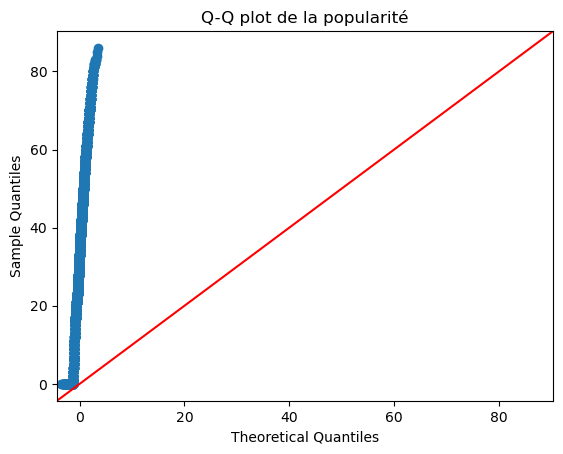

In [610]:
# Le Q-Q plot compare les quantiles observés
# aux quantiles théoriques d'une distribution normale.
sm.qqplot(
    popularity_sample,
    line="45"
)

plt.title(
    "Q-Q plot de la popularité"
)

plt.show()

In [611]:
# Variables audio utilisées dans la matrice.
correlation_vars = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

# Corrélation de Spearman :
# adaptée aux relations monotones et moins sensible
# à la non-normalité et aux valeurs extrêmes.
corr_matrix = (
    df_tracks[correlation_vars]
    .corr(method="spearman")
)

corr_matrix

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
danceability,1.000,0.050,0.116,0.152,-0.054,-0.158,-0.148,0.477,-0.048
energy,0.050,1.000,0.753,0.351,-0.712,-0.043,0.182,0.205,0.250
loudness,0.116,0.753,1.000,0.218,-0.537,-0.299,0.115,0.227,0.209
speechiness,0.152,0.351,0.218,1.000,-0.216,-0.051,0.095,0.082,0.109
acousticness,-0.054,-0.712,-0.537,-0.216,1.000,-0.094,-0.045,-0.023,-0.227
instrumentalness,-0.158,-0.043,-0.299,-0.051,-0.094,1.000,-0.105,-0.334,-0.013
liveness,-0.148,0.182,0.115,0.095,-0.045,-0.105,1.000,0.008,0.015
valence,0.477,0.205,0.227,0.082,-0.023,-0.334,0.008,1.000,0.075
tempo,-0.048,0.250,0.209,0.109,-0.227,-0.013,0.015,0.075,1.000


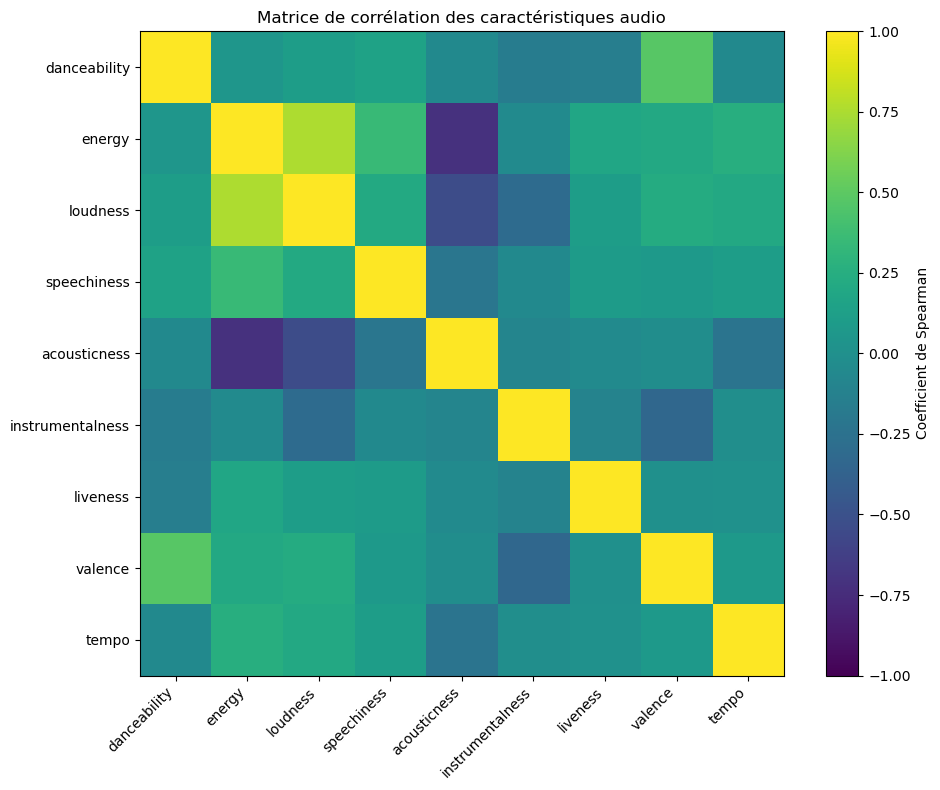

In [612]:
# Visualisation de la matrice de corrélation.
fig, ax = plt.subplots(
    figsize=(10, 8)
)

image = ax.imshow(
    corr_matrix,
    vmin=-1,
    vmax=1
)

ax.set_xticks(
    range(len(correlation_vars))
)

ax.set_yticks(
    range(len(correlation_vars))
)

ax.set_xticklabels(
    correlation_vars,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    correlation_vars
)

# Ajouter une barre indiquant l'échelle -1 à +1.
plt.colorbar(
    image,
    label="Coefficient de Spearman"
)

plt.title(
    "Matrice de corrélation des caractéristiques audio"
)

plt.tight_layout()

plt.show()

### Lecture de la matrice de corrélation

La matrice met en évidence plusieurs relations notables entre les caractéristiques audio.

La relation la plus forte observée concerne notamment `energy` et `loudness`, qui sont fortement corrélées positivement.

À l'inverse, `energy` et `acousticness` présentent une relation négative importante : les morceaux très énergétiques tendent généralement à être moins acoustiques.

Ces résultats montrent que certaines caractéristiques audio du catalogue ne sont pas indépendantes les unes des autres et permettent d'identifier des profils sonores cohérents.

In [613]:
# Transformation de la matrice afin de récupérer
# uniquement les paires différentes de variables.
upper_triangle = (
    corr_matrix
    .where(
        np.triu(
            np.ones(corr_matrix.shape),
            k=1
        ).astype(bool)
    )
)

# Convertir en tableau et trier par force absolue.
strongest_correlations = (
    upper_triangle
    .stack()
    .rename("correlation")
    .to_frame()
)

strongest_correlations[
    "correlation_absolue"
] = (
    strongest_correlations[
        "correlation"
    ].abs()
)

strongest_correlations.sort_values(
    "correlation_absolue",
    ascending=False
).head(10)

correlation  correlation_absolue
energy           loudness                0.753                0.753
                 acousticness           -0.712                0.712
loudness         acousticness           -0.537                0.537
danceability     valence                 0.477                0.477
energy           speechiness             0.351                0.351
instrumentalness valence                -0.334                0.334
loudness         instrumentalness       -0.299                0.299
energy           tempo                   0.250                0.250
loudness         valence                 0.227                0.227
acousticness     tempo                  -0.227                0.227

### Vérification de la normalité de `energy` et `loudness`

Avant de choisir le test de corrélation entre `energy` et `loudness`, nous vérifions la forme de leurs distributions.

Le test de Shapiro-Wilk est appliqué sur un échantillon reproductible de 5 000 observations pour chaque variable.

- **H0 :** la distribution est compatible avec une loi normale.
- **H1 :** la distribution n'est pas compatible avec une loi normale.
- **Seuil :** α = 0,05.

Le test est complété par un Q-Q plot afin de ne pas baser la décision uniquement sur la p-value.


--- energy ---
Statistique W : 0.9456
p-value : < 0,001
Rejet de H0 : la distribution n'est pas compatible avec une loi normale.


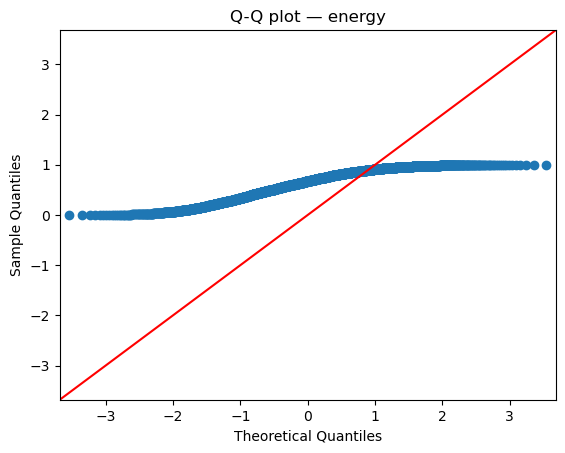


--- loudness ---
Statistique W : 0.8440
p-value : < 0,001
Rejet de H0 : la distribution n'est pas compatible avec une loi normale.


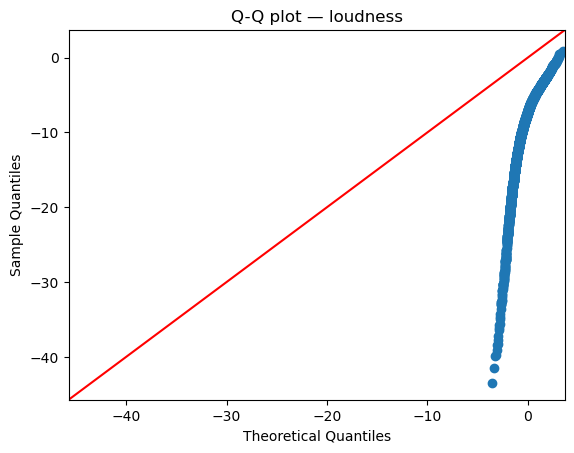

In [614]:
# ============================================================
# NORMALITÉ DE ENERGY ET LOUDNESS
# ============================================================

for variable in ["energy", "loudness"]:

    # Échantillon reproductible de 5 000 observations
    sample = (
        df_tracks[variable]
        .dropna()
        .sample(
            n=5000,
            random_state=42
        )
    )

    # Test de Shapiro-Wilk
    stat, p_normality = shapiro(sample)

    print(f"\n--- {variable} ---")
    print(f"Statistique W : {stat:.4f}")

    if p_normality < 0.001:
        print("p-value : < 0,001")
    else:
        print(f"p-value : {p_normality:.4f}")

    if p_normality < alpha:
        print(
            "Rejet de H0 : la distribution n'est pas "
            "compatible avec une loi normale."
        )
    else:
        print(
            "H0 non rejetée : la normalité "
            "ne peut pas être exclue."
        )

    # Q-Q plot
    sm.qqplot(
        sample,
        line="45"
    )

    plt.title(
        f"Q-Q plot — {variable}"
    )

    plt.show()

## Question 1 — Les caractéristiques audio sont-elles liées entre elles ?

### Choix du test de corrélation

Les variables `energy` et `loudness` sont deux variables quantitatives.

L’examen de leurs distributions, complété par le test de Shapiro-Wilk et les Q-Q plots, permet de vérifier si l’hypothèse de normalité est raisonnable.

Dans ce projet, nous cherchons surtout à mesurer une **relation monotone** entre les deux variables, c’est-à-dire à vérifier si, globalement, lorsque l’`energy` augmente, le `loudness` tend également à augmenter ou diminuer.

Le **coefficient de Spearman** est retenu car il repose sur les rangs, ne suppose pas une relation strictement linéaire et est plus robuste aux valeurs atypiques et aux écarts à la normalité que le coefficient de Pearson.

- **H0 :** il n’existe pas d’association monotone entre `energy` et `loudness`.
- **H1 :** il existe une association monotone entre `energy` et `loudness`.
- **Seuil de significativité :** α = 0,05.

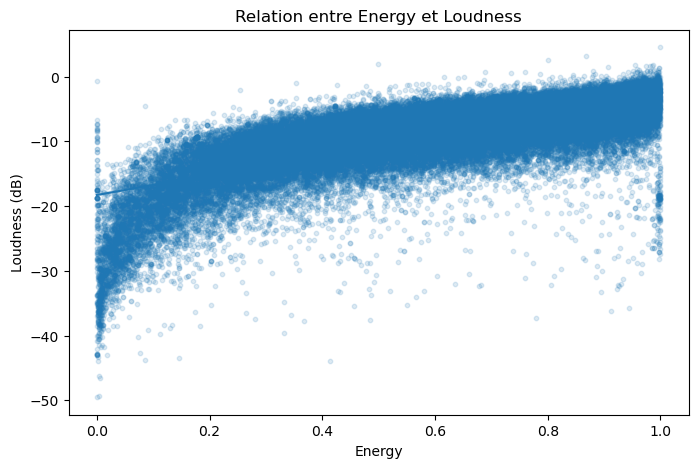

In [615]:
# Nuage de points entre Energy et Loudness.
plt.figure(figsize=(8, 5))

plt.scatter(
    df_tracks["energy"],
    df_tracks["loudness"],
    alpha=0.15,
    s=10
)

# Calcul d'une droite linéaire uniquement pour
# faciliter la lecture visuelle de la tendance.
slope, intercept = np.polyfit(
    df_tracks["energy"],
    df_tracks["loudness"],
    1
)

x_line = np.linspace(
    df_tracks["energy"].min(),
    df_tracks["energy"].max(),
    100
)

y_line = (
    slope * x_line + intercept
)

plt.plot(
    x_line,
    y_line
)

plt.xlabel("Energy")
plt.ylabel("Loudness (dB)")
plt.title(
    "Relation entre Energy et Loudness"
)

plt.show()

In [616]:
# Calcul du coefficient rho de Spearman
# et de sa p-value.
rho, p_value = spearmanr(
    df_tracks["energy"],
    df_tracks["loudness"]
)

print(
    f"Coefficient de Spearman : "
    f"{rho:.3f}"
)

print(
    f"p-value : {p_value:.4g}"
)

Coefficient de Spearman : 0.753
p-value : 0


In [617]:
if p_value < alpha:
    print(
        "Rejet de H0 : une association statistiquement "
        "significative existe entre Energy et Loudness."
    )
else:
    print(
        "H0 non rejetée : aucune association statistiquement "
        "significative n'est mise en évidence."
    )

Rejet de H0 : une association statistiquement significative existe entre Energy et Loudness.


La relation entre l'énergie et le niveau sonore est statistiquement significative.

Le coefficient de Spearman indique également l'intensité de cette association. Cela permet de déterminer si le lien est seulement détectable grâce au grand nombre d'observations ou s'il représente également une relation importante d'un point de vue métier.
### Conclusion — Energy et Loudness

Le test de Spearman met en évidence une **forte corrélation positive** entre l'énergie et le niveau sonore des morceaux (`ρ = 0,753`, `p < 0,001`).

L'hypothèse nulle d'absence de corrélation est donc rejetée.

La relation n'est pas seulement statistiquement significative : la valeur élevée du coefficient de Spearman indique également une association importante.

D'un point de vue métier, les morceaux perçus comme plus énergétiques ont tendance à présenter un niveau sonore plus élevé. MeloWave peut donc considérer ces deux caractéristiques comme fortement liées lorsqu'il cherche à caractériser le profil sonore de son catalogue.

## Question 2 — La popularité diffère-t-elle réellement selon le genre ?

### Choix du test : Kruskal-Wallis

Nous cherchons à déterminer si la popularité diffère selon le genre musical.

- `track_genre` est une variable **qualitative** comportant plusieurs groupes.
- `popularity` est une variable **quantitative**.

La distribution de `popularity` présente des écarts à la normalité et comporte notamment une proportion importante de valeurs égales à 0.

Dans ce contexte, nous retenons le **test non paramétrique de Kruskal-Wallis**, qui permet de comparer plusieurs groupes indépendants à partir des rangs des observations, sans supposer que la variable étudiée suit une loi normale dans chaque groupe.

Pour mieux respecter l'hypothèse d'indépendance entre les groupes, le test est réalisé sur `df_single_genre`, qui contient uniquement les morceaux associés à un seul genre.

- **H0 :** les distributions de popularité sont identiques entre les genres.
- **H1 :** au moins un genre présente une distribution de popularité différente.
- **Seuil de significativité :** α = 0,05.

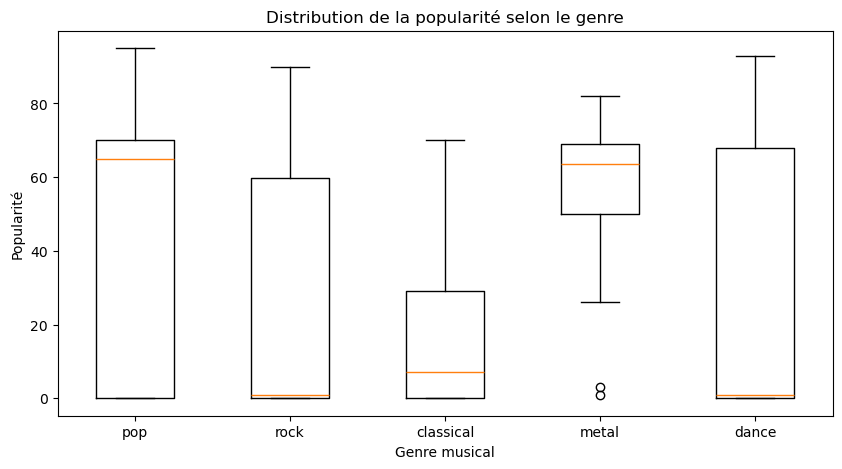

In [618]:
# Quelques genres contrastés sont sélectionnés
# uniquement pour rendre le graphique lisible.
genres_for_plot = [
    "pop",
    "rock",
    "classical",
    "metal",
    "dance"
]

plot_data = [
    df_single_genre.loc[
        df_single_genre["track_genre"] == genre,
        "popularity"
    ]
    for genre in genres_for_plot
]

plt.figure(figsize=(10, 5))

plt.boxplot(
    plot_data,
    tick_labels=genres_for_plot
)

plt.xlabel("Genre musical")
plt.ylabel("Popularité")
plt.title(
    "Distribution de la popularité selon le genre"
)

plt.show()

Pour conserver un graphique lisible, seuls cinq genres contrastés sont représentés ci-dessus. Le test de Kruskal-Wallis est quant à lui réalisé sur l'ensemble des genres présents dans le jeu de données utilisé pour l'analyse.

In [619]:
# Création d'un tableau de valeurs de popularité
# pour chaque genre musical.
groups = [
    group["popularity"].values
    for _, group
    in df_single_genre.groupby(
        "track_genre"
    )
]

In [620]:
# Test non paramétrique de Kruskal-Wallis.
kruskal_stat, kruskal_p = kruskal(
    *groups
)

print(
    f"Statistique H : "
    f"{kruskal_stat:.3f}"
)

print(
    f"p-value : "
    f"{kruskal_p:.4g}"
)

Statistique H : 32780.365
p-value : 0


In [621]:
# Calcul d'une taille d'effet globale pour le test de Kruskal-Wallis.
# Epsilon carré permet de mesurer l'importance des différences entre les genres,
# indépendamment de la seule significativité statistique.

n = len(df_single_genre)
k = df_single_genre["track_genre"].nunique()

epsilon_squared = (
    (kruskal_stat - k + 1)
    / (n - k)
)

print(
    f"Epsilon carré : "
    f"{epsilon_squared:.3f}"
)

Epsilon carré : 0.446


### Conclusion — Popularité selon le genre

Le test de Kruskal-Wallis met en évidence une différence statistiquement significative de popularité entre les genres (`H = 32 780,365`, `p < 0,001`).

L'hypothèse nulle selon laquelle les distributions de popularité sont similaires entre tous les genres est donc rejetée.

La taille d'effet globale, mesurée par epsilon carré (`ε² ≈ 0,446`), indique que les différences observées sont également importantes en pratique.

On peut donc conclure que le genre musical est associé à des niveaux de popularité différents dans le catalogue MeloWave.

Cependant, le test de Kruskal-Wallis indique uniquement qu'au moins un genre diffère des autres : il ne permet pas, à lui seul, d'identifier précisément quelles paires de genres présentent des différences significatives.

## Question 3 — Le contenu explicite dépend-il du genre musical ?

Le comité souhaite savoir si la proportion de morceaux comportant du contenu explicite varie selon le genre musical.

Les deux variables étudiées sont qualitatives :

- `track_genre`, qui représente le genre musical ;
- `explicit`, variable binaire indiquant si le morceau contient ou non du contenu explicite.

Nous utilisons donc un **test du khi² d'indépendance**, adapté à l'étude de la relation entre deux variables qualitatives.

**Hypothèses du test :**

- **H0 :** le genre musical et le caractère explicite sont indépendants.
- **H1 :** il existe une association entre le genre musical et le caractère explicite.

Le seuil de significativité retenu est **α = 5 %**.

In [622]:
if kruskal_p < alpha:
    print(
        "Rejet de H0 : la popularité diffère "
        "significativement entre au moins certains genres."
    )
else:
    print(
        "H0 non rejetée : aucune différence globale "
        "de popularité n'est mise en évidence."
    )

Rejet de H0 : la popularité diffère significativement entre au moins certains genres.


In [623]:
# Tableau croisant :
# - genre musical
# - caractère explicite True / False
contingency_table = pd.crosstab(
    df_single_genre["track_genre"],
    df_single_genre["explicit"]
)

contingency_table

explicit,False,True
track_genre,,
acoustic,772,48
afrobeat,925,18
alt-rock,152,7
alternative,87,71
ambient,710,3
...,...,...
techno,379,9
trance,698,10
trip-hop,867,37


In [624]:
# Test du khi² d'indépendance.
chi2, chi2_p, dof, expected = (
    chi2_contingency(
        contingency_table
    )
)

print(f"Chi² : {chi2:.3f}")
print(f"Degrés de liberté : {dof}")
print(f"p-value : {chi2_p:.4g}")

Chi² : 16545.621
Degrés de liberté : 111
p-value : 0


In [625]:
# Les effectifs théoriques du test du khi²
# doivent être suffisamment élevés.
expected_df = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

print(
    "Nombre de cellules avec effectif théorique < 5 :",
    (expected_df < 5).sum().sum()
)

Nombre de cellules avec effectif théorique < 5 : 0


In [626]:
# La p-value indique si l'association est détectable.
# Le V de Cramér mesure son intensité.

n = contingency_table.to_numpy().sum()

phi_squared = chi2 / n

rows, columns = contingency_table.shape

cramers_v = np.sqrt(
    phi_squared /
    min(rows - 1, columns - 1)
)

print(
    f"V de Cramér : "
    f"{cramers_v:.3f}"
)

V de Cramér : 0.475


### Conclusion — Genre et contenu explicite

Le test du khi² met en évidence une dépendance statistiquement significative entre le genre musical et le caractère explicite des morceaux (`χ²(111) = 16 545,621`, `p < 0,001`).

L'hypothèse nulle d'indépendance entre les deux variables est donc rejetée.

Les effectifs théoriques respectent les conditions d'utilisation du test, puisqu'aucune cellule ne présente un effectif attendu inférieur à 5.

Le V de Cramér vaut `0,475`, ce qui indique que l'association entre le genre et le contenu explicite présente une ampleur importante.

D'un point de vue métier, la proportion de morceaux explicites varie donc nettement selon les genres. Cette information peut être utile à MeloWave pour adapter ses recommandations en fonction du public, du positionnement éditorial ou des contraintes des labels.

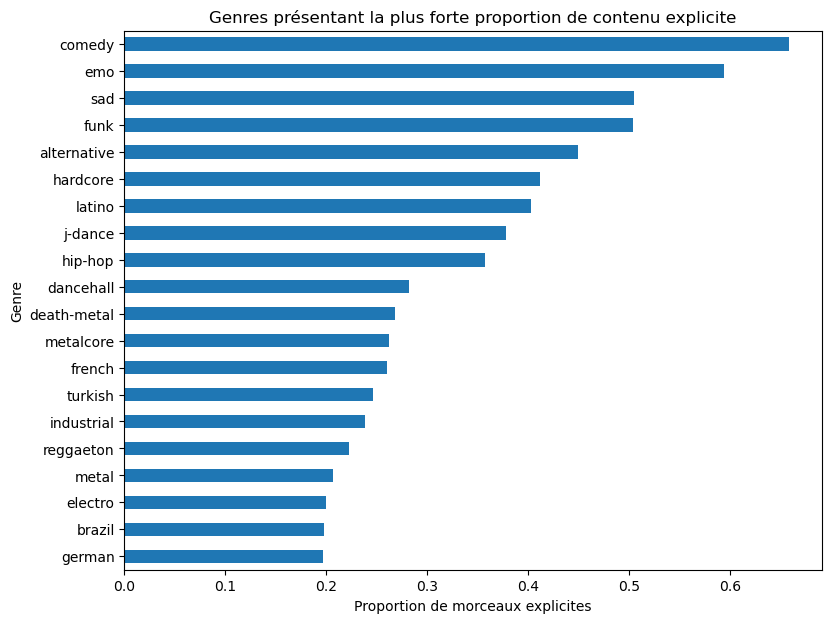

In [627]:
# Proportion de morceaux explicites pour chaque genre.
explicit_rate = (
    df_single_genre
    .groupby("track_genre")["explicit"]
    .mean()
    .sort_values(
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(9, 7))

explicit_rate.sort_values().plot(
    kind="barh"
)

plt.xlabel(
    "Proportion de morceaux explicites"
)

plt.ylabel("Genre")

plt.title(
    "Genres présentant la plus forte proportion "
    "de contenu explicite"
)

plt.show()

# Conclusion de la mission 1

L'analyse a permis de réaliser un audit complet du catalogue MeloWave, puis d'étudier les principales caractéristiques audio des morceaux.

Le jeu de données initial contenait 114 000 observations. Une observation comportant des informations d'identification manquantes ainsi que 450 doublons stricts ont été supprimés. Les morceaux associés à plusieurs genres ont en revanche été conservés car cette répétition correspond à une caractéristique réelle du catalogue et non à une erreur de qualité.

L'analyse exploratoire met en évidence des distributions parfois fortement asymétriques ainsi que plusieurs valeurs statistiquement atypiques. Ces valeurs ont été conservées lorsqu'elles restaient plausibles d'un point de vue métier. La popularité présente notamment une proportion de 10,42 % de morceaux ayant un score égal à zéro.

Les tests statistiques permettent de répondre aux trois questions du comité :

- **Caractéristiques audio :** `energy` et `loudness` présentent une forte corrélation positive (`ρ = 0,753`, `p < 0,001`). Les morceaux les plus énergétiques tendent donc à présenter un niveau sonore plus élevé.

- **Popularité selon le genre :** le test de Kruskal-Wallis met en évidence des différences significatives de popularité entre les genres (`H = 32 780,365`, `p < 0,001`). La taille d'effet globale (`ε² ≈ 0,446`) indique également que ces différences sont importantes en pratique. Le test permet toutefois seulement de conclure qu'au moins un genre diffère des autres.

- **Contenu explicite selon le genre :** le test du khi² montre une dépendance significative entre le genre musical et le caractère explicite (`χ²(111) = 16 545,621`, `p < 0,001`). Le V de Cramér de `0,475` indique que cette association présente également une ampleur importante.

Ces résultats montrent que le catalogue MeloWave présente des profils sonores et des comportements de popularité très différents selon les genres. Ils permettent ainsi d'appuyer les recommandations adressées aux labels sur des éléments quantifiés plutôt que sur de simples intuitions.